# 0. 준비

In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import warnings; warnings.filterwarnings('ignore')

In [2]:
# 그래프 폰트 설정
import matplotlib
from matplotlib import font_manager

for _f in ['Malgun Gothic', 'AppleGothic', 'NanumGothic',
           'Noto Sans CJK KR', 'Noto Sans CJK JP']:
    if _f in {f.name for f in font_manager.fontManager.ttflist}:
        plt.rcParams['font.family'] = _f
        break
plt.rcParams['axes.unicode_minus'] = False   # 음수 부호 깨짐 방지
print('font:', plt.rcParams['font.family'])

font: ['Malgun Gothic']


In [3]:
df=pd.read_csv('insurance.csv')
df.tail()
# age: 나이, sex: 성별, bmi: BMI지수, children: 자녀수, smoker: 흡연여부, region: 거주지역
# charges: float형이고, column의 통계량을 확인해야 알 수 있음

,age,sex,bmi,children,smoker,region,charges
1333,50,male,30.97,3,no,northwest,10600.5483
1334,18,female,31.92,0,no,northeast,2205.9808
1335,18,female,36.85,0,no,southeast,1629.8335
1336,21,female,25.80,0,no,southwest,2007.9450
1337,61,female,29.07,0,yes,northwest,29141.3603


# 1. 데이터 기초 통계 확인

In [4]:
print(df.shape)
print(df.head(2).T)

(1338, 7)
                  0          1
age              19         18
sex          female       male
bmi            27.9      33.77
children          0          1
smoker          yes         no
region    southwest  southeast
charges   16884.924  1725.5523


In [5]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 94.5 KB
None


In [23]:
df.describe().round(2)

,age,bmi,children,charges,sex_code,smoker_code,region_code
count,1338.00,1338.00,1338.00,1338.00,1338.00,1338.0,1338.00
mean,39.21,30.66,1.09,13270.42,0.51,0.2,1.54
std,14.05,6.10,1.21,12110.01,0.50,0.4,1.13
min,18.00,15.96,0.00,1121.87,0.00,0.0,0.00
25%,27.00,26.30,0.00,4740.29,0.00,0.0,1.00
50%,39.00,30.40,1.00,9382.03,1.00,0.0,2.00
75%,51.00,34.69,2.00,16639.91,1.00,0.0,3.00
max,64.00,53.13,5.00,63770.43,1.00,1.0,3.00


In [7]:
df.describe(include='all')
# 결측치 포함 서술

,age,sex,bmi,children,smoker,region,charges
count,1338.000000,1338,1338.000000,1338.000000,1338,1338,1338.000000
unique,NaN,2,NaN,NaN,2,4,NaN
top,NaN,male,NaN,NaN,no,southeast,NaN
freq,NaN,676,NaN,NaN,1064,364,NaN
mean,39.207025,NaN,30.663397,1.094918,NaN,NaN,13270.422265
std,14.049960,NaN,6.098187,1.205493,NaN,NaN,12110.011237
min,18.000000,NaN,15.960000,0.000000,NaN,NaN,1121.873900
25%,27.000000,NaN,26.296250,0.000000,NaN,NaN,4740.287150
50%,39.000000,NaN,30.400000,1.000000,NaN,NaN,9382.033000
75%,51.000000,NaN,34.693750,2.000000,NaN,NaN,16639.912515


In [8]:
df.describe(include='O')
# 범주형 자료만

,sex,smoker,region
count,1338,1338,1338
unique,2,2,4
top,male,no,southeast
freq,676,1064,364


In [9]:
df.isna().sum() # 결측치 없음

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [ ]:
df.charges.skew() # charges의 왜도

np.float64(1.5158796580240388)

### 변수 정리

| column | 의미 | 유형 | 결측 |
|---|---|---|---|
| age | 나이 | 수치형-연속 | 0 |
| sex | 성별 | 범주형-명목 | 0 |
| bmi | BMI | 수치형-연속 | 0 |
| children | 자녀수 | 수치형-이산 | 0 |
| smoker | 흡연여부 | 범주형-명목 | 0 |
| region | 지역 | 범주형-명목 | 0 |
| charges | 보험료 | 수치형-연속 | 0 |

### 수치형 자료 기초통계
| | age | bmi | children | charges |
|---|---|---|---|---|
| mean | 39.207025 | 30.663397 | 1.094918 | 13270.422265 |
| std | 14.049960 | 6.098187 | 1.205493 | 12110.011237 |
| med | 39.000000 | 30.400000 | 1.000000 | 9382.03300 |
* age는 평균과 중앙값이 비슷하여 대칭적이고 표준편차가 높아 나이대가 고르게 분포
* bmi도 마찬가지
* children은 평균 자녀수 1명대
* charges는 왜도가 큼 - skewed to the right

---

# 2. 범주형 자료

### 성별로 나타낼 수 있는 데이터
1. 나이 분포
2. BMI 분포
3. 흡연률
4. 지역별 성별 인구
5. 보험료 분포

### 범주형 -> 수치형-이산 전환

* sex_code: 여성=0, 남성=1
* smoker_code: 비흡연=0, 흡연=1
* region_code: NE=0,NW=1,SW=2,SE=3

In [ ]:
# 범주 순서를 명시해서 코드값을 고정 (원본 insurance.csv는 건드리지 않음)
cat_orders = {
    'sex':    ['female', 'male'],                                   # 0, 1
    'smoker': ['no', 'yes'],                                        # 0, 1
    'region': ['northeast', 'northwest', 'southwest', 'southeast'], # 0, 1, 2, 3
}

for col, order in cat_orders.items():
    df[col + '_code'] = pd.Categorical(df[col], categories=order).codes

# 코드 - 원래 값 대응표 (그래프 눈금 라벨 붙일 때 사용)
code_labels = {col: dict(enumerate(order)) for col, order in cat_orders.items()}
print(code_labels)

df[['sex', 'sex_code', 'smoker', 'smoker_code', 'region', 'region_code']].head()

{'sex': {0: 'female', 1: 'male'}, 'smoker': {0: 'no', 1: 'yes'}, 'region': {0: 'northeast', 1: 'northwest', 2: 'southwest', 3: 'southeast'}}


,sex,sex_code,smoker,smoker_code,region,region_code
0,female,0,yes,1,southwest,2
1,male,1,no,0,southeast,3
2,male,1,no,0,southeast,3
3,male,1,no,0,northwest,1
4,male,1,no,0,northwest,1


### 1) 나이 분포

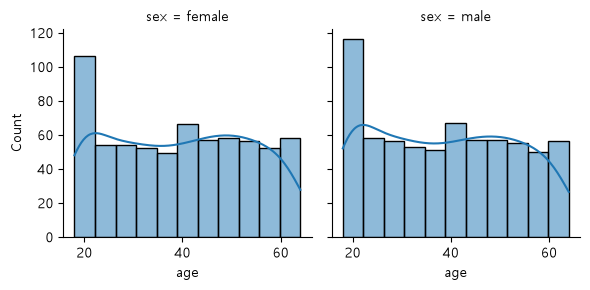

In [12]:
g=sns.FacetGrid(df,col='sex')
g=g.map(sns.histplot,'age',kde=True)

**확인되는 사항**
* 20세 데이터를 제외하곤 나이대별로 일정한 인원수 분포
* 성별에 따른 차이도 거의 없음
* 자료 자체가 정제됐거나 선별하여 배포된 것으로 추정

### 2) BMI 분포

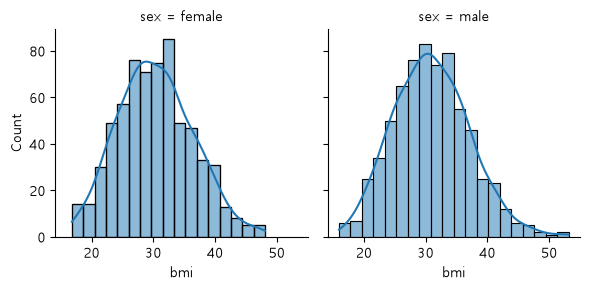

In [13]:
g=sns.FacetGrid(df,col='sex')
g=g.map(sns.histplot,'bmi',kde=True)

**확인되는 사항**
* 비만인 인원이 절반 이상(BMI 25 이상, 한국기준)
* 여성이 남성이 비해 약간 낮은 경향
* 남성은 BMI 50 이상 꼬리가 있음

### 3) 흡연률


In [ ]:
df.groupby('sex')['smoker_code'].mean()

sex
female    0.173716
male      0.235207
Name: smoker_code, dtype: float64

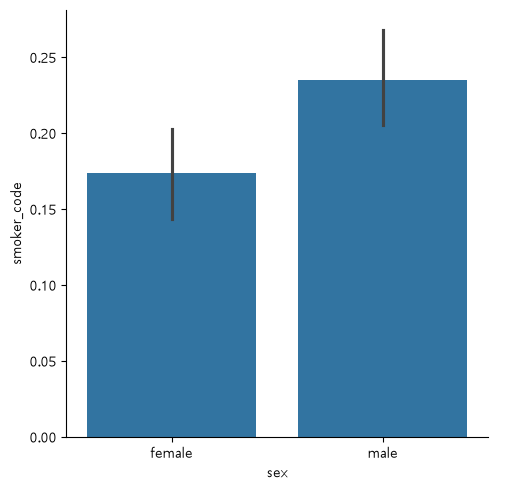

In [16]:
g=sns.catplot(x='sex',y='smoker_code',data=df,kind='bar')
plt.show()

**확인되는 사항**
* 여성의 흡연률이 남성 대비 6%p 낮음

### 4) 지역별-성별 인구

In [28]:
df.groupby('region')['charges'].agg(
    인원='size',평균='mean',중앙값='median',표준편차='std'
    ).round(0)

,인원,평균,중앙값,표준편차
region,,,,
northeast,324,13406.0,10058.0,11256.0
northwest,325,12418.0,8966.0,11072.0
southeast,364,14735.0,9294.0,13971.0
southwest,325,12347.0,8799.0,11557.0


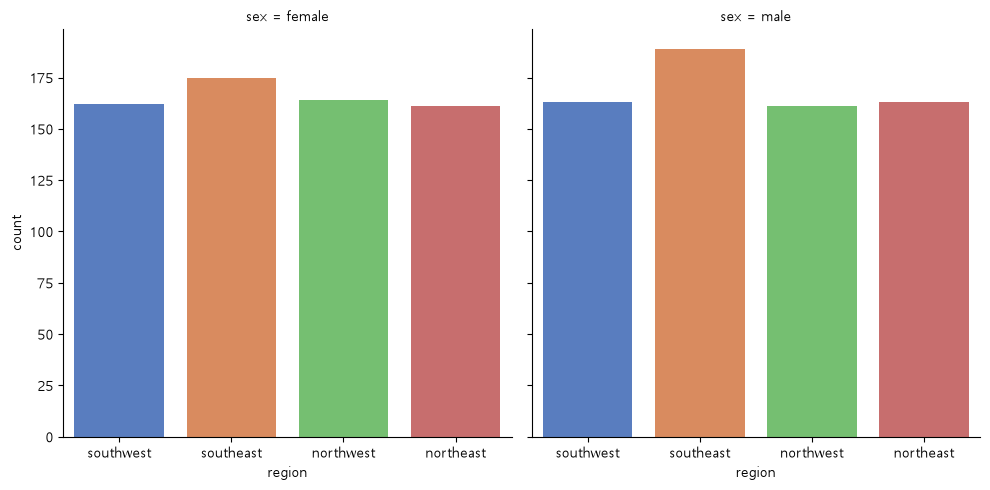

In [22]:
g=sns.catplot(x='region',col='sex',data=df,kind='count',palette='muted')

**확인되는 사항**
* 성별 차이 없음, 지역별 고른 분포(SE지역 다소 높음)
* 데이터 자체가 균일하게 취합됨

### 5) 보험료-성별 분포

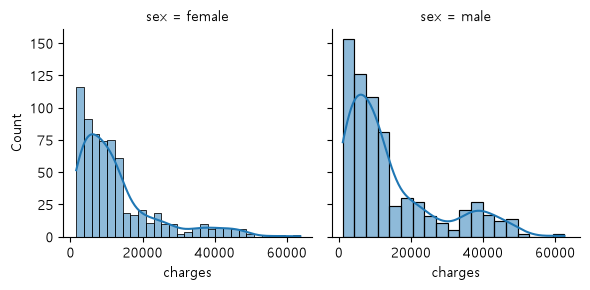

In [25]:
g=sns.FacetGrid(df,col='sex')
g=g.map(sns.histplot,'charges',kde=True)

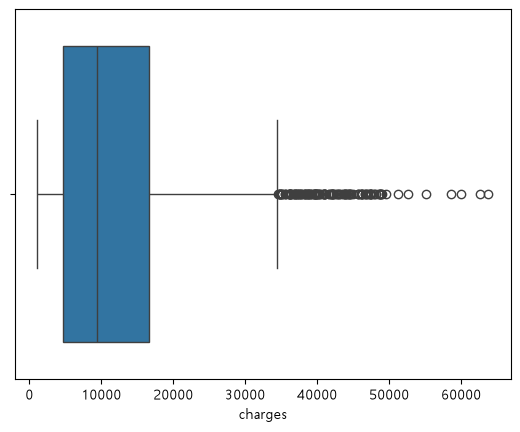

In [27]:
g=sns.boxplot(data=df,x='charges',ax=plt.subplot())

**확인되는 사항**
* 성별에 따른 보험료 격차가 다소 있음

### region과 charges 관계

<Axes: xlabel='region', ylabel='charges'>

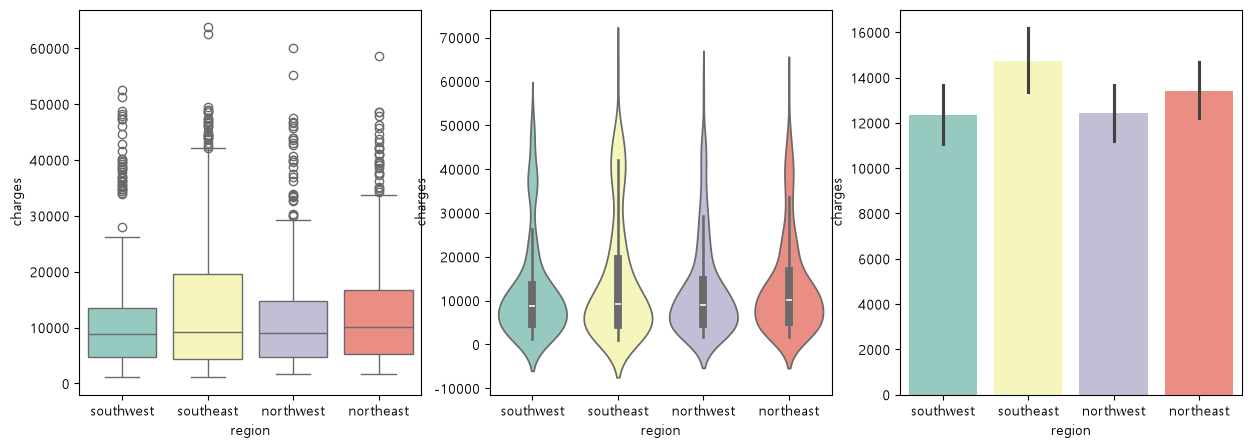

In [ ]:
fig,axes=plt.subplots(1,3,figsize=(15,5))

# boxplot
sns.boxplot(data=df, x='region', y='charges', ax=axes[0], palette='Set3')
# violinplot
sns.violinplot(data=df, x='region', y='charges', ax=axes[1], palette='Set3')
# barplot
sns.barplot(data=df, x='region', y='charges', ax=axes[2], palette='Set3')

In [ ]:
# 통계 검정 - ANOVA 방법
from scipy import stats

groups=[df[df['region']==r]['charges'] for r in df['region'].unique()]
f_stat,p_val=stats.f_oneway(*groups)

print(f'F = {f_stat:.2f}, p = {p_val:.4f}')
# p < 0.05로 우연으로 보기 어렵다

F = 2.97, p = 0.0309


* p-value는 귀무가설 '차이가 없음'을 기각
* 분포상으로는 유의미한 결과 찾을 수 없음 - 지역별로 동일한 분포

---
# 3. 수치형 자료

### 1) age에 따른 charges 분포

<Axes: xlabel='age', ylabel='charges'>

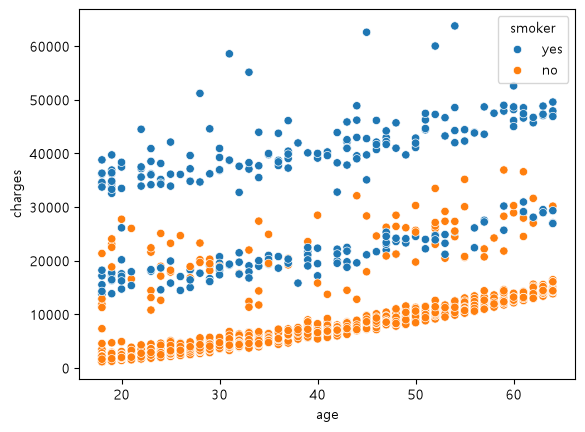

In [75]:
sns.scatterplot(data=df,x='age',y='charges',hue='smoker')

In [37]:
# 나이대별 세부 분포
df['age_band']=pd.cut(df['age'],bins=[17,29,39,49,59,1000],
                      labels=['18~29세','30대','40대','50대','60대 이상'])
df.groupby('age_band')['charges'].agg(인원='size', 평균='mean', 중앙값='median').round(0)

,인원,평균,중앙값
age_band,,,
18~29세,417,9182.0,3214.0
30대,257,11739.0,6082.0
40대,279,14399.0,8606.0
50대,271,16495.0,11730.0
60대 이상,114,21248.0,14255.0


In [43]:
# age - charges 상관계수
print(f'age - charges 상관계수: {df['age'].corr(df['charges']).round(4)}')

age - charges 상관계수: 0.299


**확인되는 사항**
* 보험료가 3개의 그룹으로 나뉘는 양상
* 연령이 올라갈수록 일정하게 오르는 경향
* 상관계수는 연령과 보험료 간 상관관계가 있다고 주장

### 2) BMI에 따른 charges의 분포

<Axes: xlabel='bmi', ylabel='charges'>

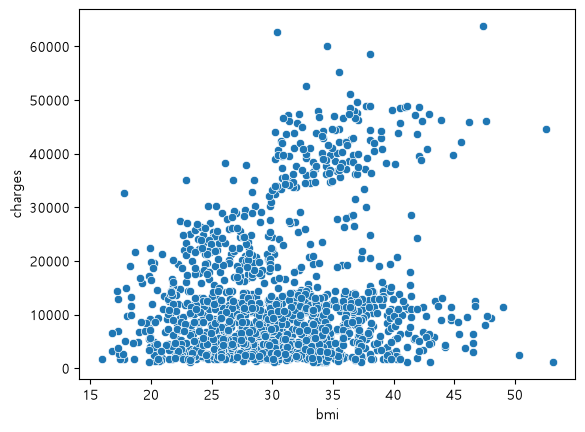

In [44]:
sns.scatterplot(data=df,x='bmi',y='charges')

<Axes: xlabel='bmi', ylabel='charges'>

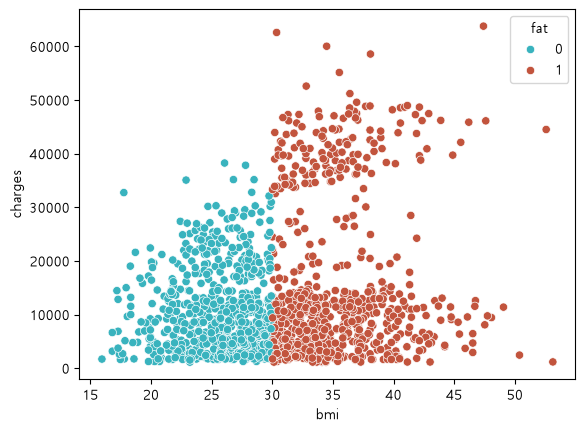

In [48]:
# BMI 30을 기준으로 보험료 그룹이 나뉘는 것으로 보임
# BMI > 30 -> 비만(1), < 30 -> 정상(0)
df['fat']=(df['bmi']>=30).astype(int)

# 이를 시각화

sns.scatterplot(data=df,x='bmi',y='charges',hue='fat',palette={0: "#39b3be",1: '#c2543d'})

In [ ]:
# 상관계수
print(f'BMI - charges 상관계수: {df['bmi'].corr(df['charges']).round(4)}')

BMI - charges 상관계수: 0.1983


**확인되는 사항**
* BMI와 보험료 간 상관관계는 부족
* BMI 30을 기준으로 보험료가 크게 올라간 그룹이 존재
* 그럼에도 불구하고 저가 그룹이 존재하여 BMI만으론 설명 근거 부족

---
# 4. 상관관계 분석

In [ ]:
df_num=df[['age','children','smoker_code','sex_code','region_code','fat','charges']].copy()
# 앞서 확인한 양상을 고려하여 bmi 대신 fat 값으로 확인
corr_value=df_num.corr()

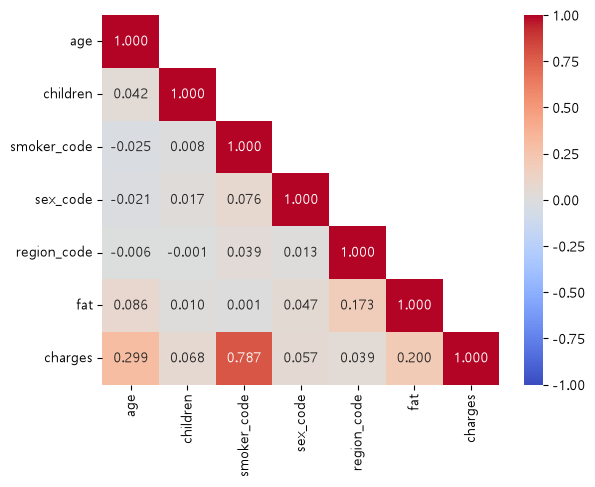

In [61]:
mask=np.zeros((7,7))
for i,row in enumerate(mask):
    for j,k in enumerate(row):
        if i<j:
            mask[i,j]=1
g=sns.heatmap(corr_value,annot=True,fmt='.3f',vmin=-1,vmax=1,cmap='coolwarm',mask=mask)
plt.show()

In [62]:
# charges와 변수들의 상관계수
print(corr_value['charges'].drop('charges').sort_values(key=abs,ascending=False).round(4))

smoker_code    0.7873
age            0.2990
fat            0.1995
children       0.0680
sex_code       0.0573
region_code    0.0395
Name: charges, dtype: float64


**확인되는 사항**
* 흡연 여부와 보험료 간 강한 상관관계 확인
* 연령과 보험료 간 상관관계 가능성 존재
### 흡연 여부를 최우선으로 고려해야 함

---
# 5. 흡연 여부와 성별에 따른 보험료 분포

In [ ]:
# 흡연률
df.groupby('sex')['smoker_code'].mean()

sex
female    0.173716
male      0.235207
Name: smoker_code, dtype: float64

In [66]:
# 흡연여부, 성별 조합별 평균 보험료
df.pivot_table(index='smoker',columns='sex',values='charges',aggfunc='mean').round(0)

sex,female,male
smoker,,
no,8762.0,8087.0
yes,30679.0,33042.0


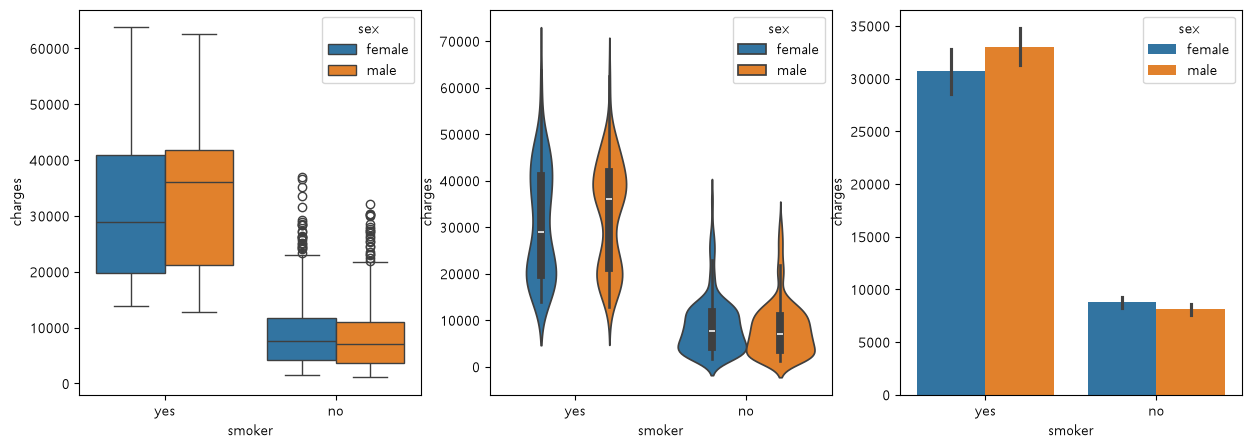

In [ ]:
fig,axes=plt.subplots(1,3,figsize=(15,5))

sns.boxplot(data=df,x='smoker',y='charges',hue='sex',ax=axes[0])

sns.violinplot(data=df,x='smoker',y='charges',hue='sex',ax=axes[1])

sns.barplot(data=df,x='smoker',y='charges',hue='sex',ax=axes[2])

plt.show()

In [74]:
# 성별 차이에 대한 통계 검정 - T-검정
for i in ['no','yes']:
    sub=df[df.smoker==i]
    m=sub[sub.sex=='male']['charges']
    f=sub[sub.sex=='female']['charges']
    t,p=stats.ttest_ind(m,f,equal_var=False)
    print(f'흡연 {i:<4}: t = {t:.4f}, p = {p:.4f}')

흡연 no  : t = -1.8396, p = 0.0661
흡연 yes : t = 1.6617, p = 0.0979


**확인되는 사실**
* 흡연자의 보험료가 비흡연자 대비 높음
* 동일 흡연 집단에서 성별과 보험료의 상관관계 낮음

---
# 6. 결론
### 1) 인사이트 요약

In [79]:
print('charges와 각 변수들 간 상관계수')
print(corr_value['charges'].drop('charges').sort_values(key=abs,ascending=False).round(4))

charges와 각 변수들 간 상관계수
smoker_code    0.7873
age            0.2990
fat            0.1995
children       0.0680
sex_code       0.0573
region_code    0.0395
Name: charges, dtype: float64


* 흡연자의 보험료가 높다 - 강한 상관관계로 성립
* 연령이 높을수록 보험료가 높다 - 약한 상관관계로 성립
* 비만 환자의 보험료가 높다 - 모호한 상관관계
* 이외 - 상관관계 없음

### 2) 보험료 예측 모델 제안

In [ ]:
df_model=pd.DataFrame({
    'age':df['age'],
    'fat':df['fat'],
    'smoker':df['smoker'],
    'charges':df['charges'],
})

In [82]:
df_model.head()

,age,fat,smoker_code,charges
0,19,0,1,16884.92400
1,18,1,0,1725.55230
2,28,1,0,4449.46200
3,33,0,0,21984.47061
4,32,0,0,3866.85520


**사용할 변수 정리**

| column | 의미 | 유형 | 비고 |
|---|---|---|---|
| age | 나이 | 수치형-연속 | 연령을 int로 입력 |
| fat | 비만 여부 | 수치형-이산 | BMI x를 기준으로 x 이상은 1, 미만은 0(x는 지역에 따라 달리함) |
| smoker | 흡연 여부 | 수치형-이산 | 흡연자는 1, 비흡연자는 0 |
| charges | 보험료 | 수치형-연속 | 기 책정된 연평균 보험료 |